In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] WARNING | pattern 'lindbladian.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_c

In [12]:
# using 'Science' style plots
plt.style.use(['science', 'high-vis'])

J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

In [13]:
def L_eff(N):
    # building matrices
    H0 = sp.Matrix(N, N, lambda i,j : sp.Symbol("J", real=True, positive=True) if ({i,j}=={0,1}) else 0)
    #V = sp.Matrix(N, N, lambda i,j : epsilon*sp.Symbol(f"epsilon_{i+1 if i<j else j+1}{j+1 if i<j else i+1}", real=True) if ({i,j}!={0,1} and (i!=0 or j!=0) and i!=j) else 0)
    V = sp.Matrix(N, N, lambda i,j : epsilon if ({i,j}!={0,1} and (i!=0 or j!=0) and i!=j) else 0)
    
    # building lindblad jump operators
    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    
    # building lindbladians
    L0, rho = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
    L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)
    
    # setting all dephasing constants to the same constant gamma
    L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})


    nullspace = [n/n.norm() for n in L0.nullspace()]
    P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
    Q = sp.eye(sp.shape(P)[0]) - P

    Leff = (-1*(Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P).applyfunc(lambda i: i.simplify(deep=True))
    Leff_red = sp.Matrix(N-1, N-1, lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))


    return rho, L0+L1, Leff, Leff_red


In [73]:
def plot_time_series(axs, N, matrix, J_val, epsilon_val, gamma_vals, initial_condition, pop_indices, label=True, reduced_matrix=False):
    # iterating through different dephasing regimes
    for col, gamma_val in enumerate(gamma_vals):
        
        # for each regime, compute long time-scale value
        timescale = (gamma_val**2 + J_val**2) / (2*N*gamma_val*epsilon_val**2)
        print(timescale)

        # numerically compute time evolution of density matrix
        times, rhos = solve_lindblad_num(
            matrix.subs({J:J_val, gamma:gamma_val, epsilon:epsilon_val}),
            0.1,
            timescale*1e2,
            timescale*1e-1,
            initial_condition,
        )

        # plotting populations
        for i, index in enumerate(pop_indices):
            if reduced_matrix and i==0:
                axs[col].plot(times, rhos[index],label=r"$\frac{|1⟩⟨1|+|2⟩⟨2|}{\sqrt2}$")
                axs[col].plot([], []) # null plot to increment color cycle
            else:
                axs[col].plot(times, 
                              rhos[index],
                              label=f"{i+2 if reduced_matrix else i+1}",
                              #linewidth=2.75*0.95**i,
                              #alpha=1*0.9**i
                             )

        # labelling
        if label: axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[col]))}}}$')
        axs[col].set_ylim(bottom=-0.3, top=1.1)
        axs[col].set_xlabel("Time (s)")
        axs[col].set_xscale('log')
        axs[col].legend(title="Site Pop.:", fontsize="x-small", title_fontsize="small", ncol = 2 if (N>3 and not reduced_matrix) or (N>4 and reduced_matrix) else 1)
        axs[col].axvline(timescale,linestyle="--", color="gray")

    # labelling
    #axs[0].set_ylabel("Site Populations")


# n = 3

3333333.3333333335


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334


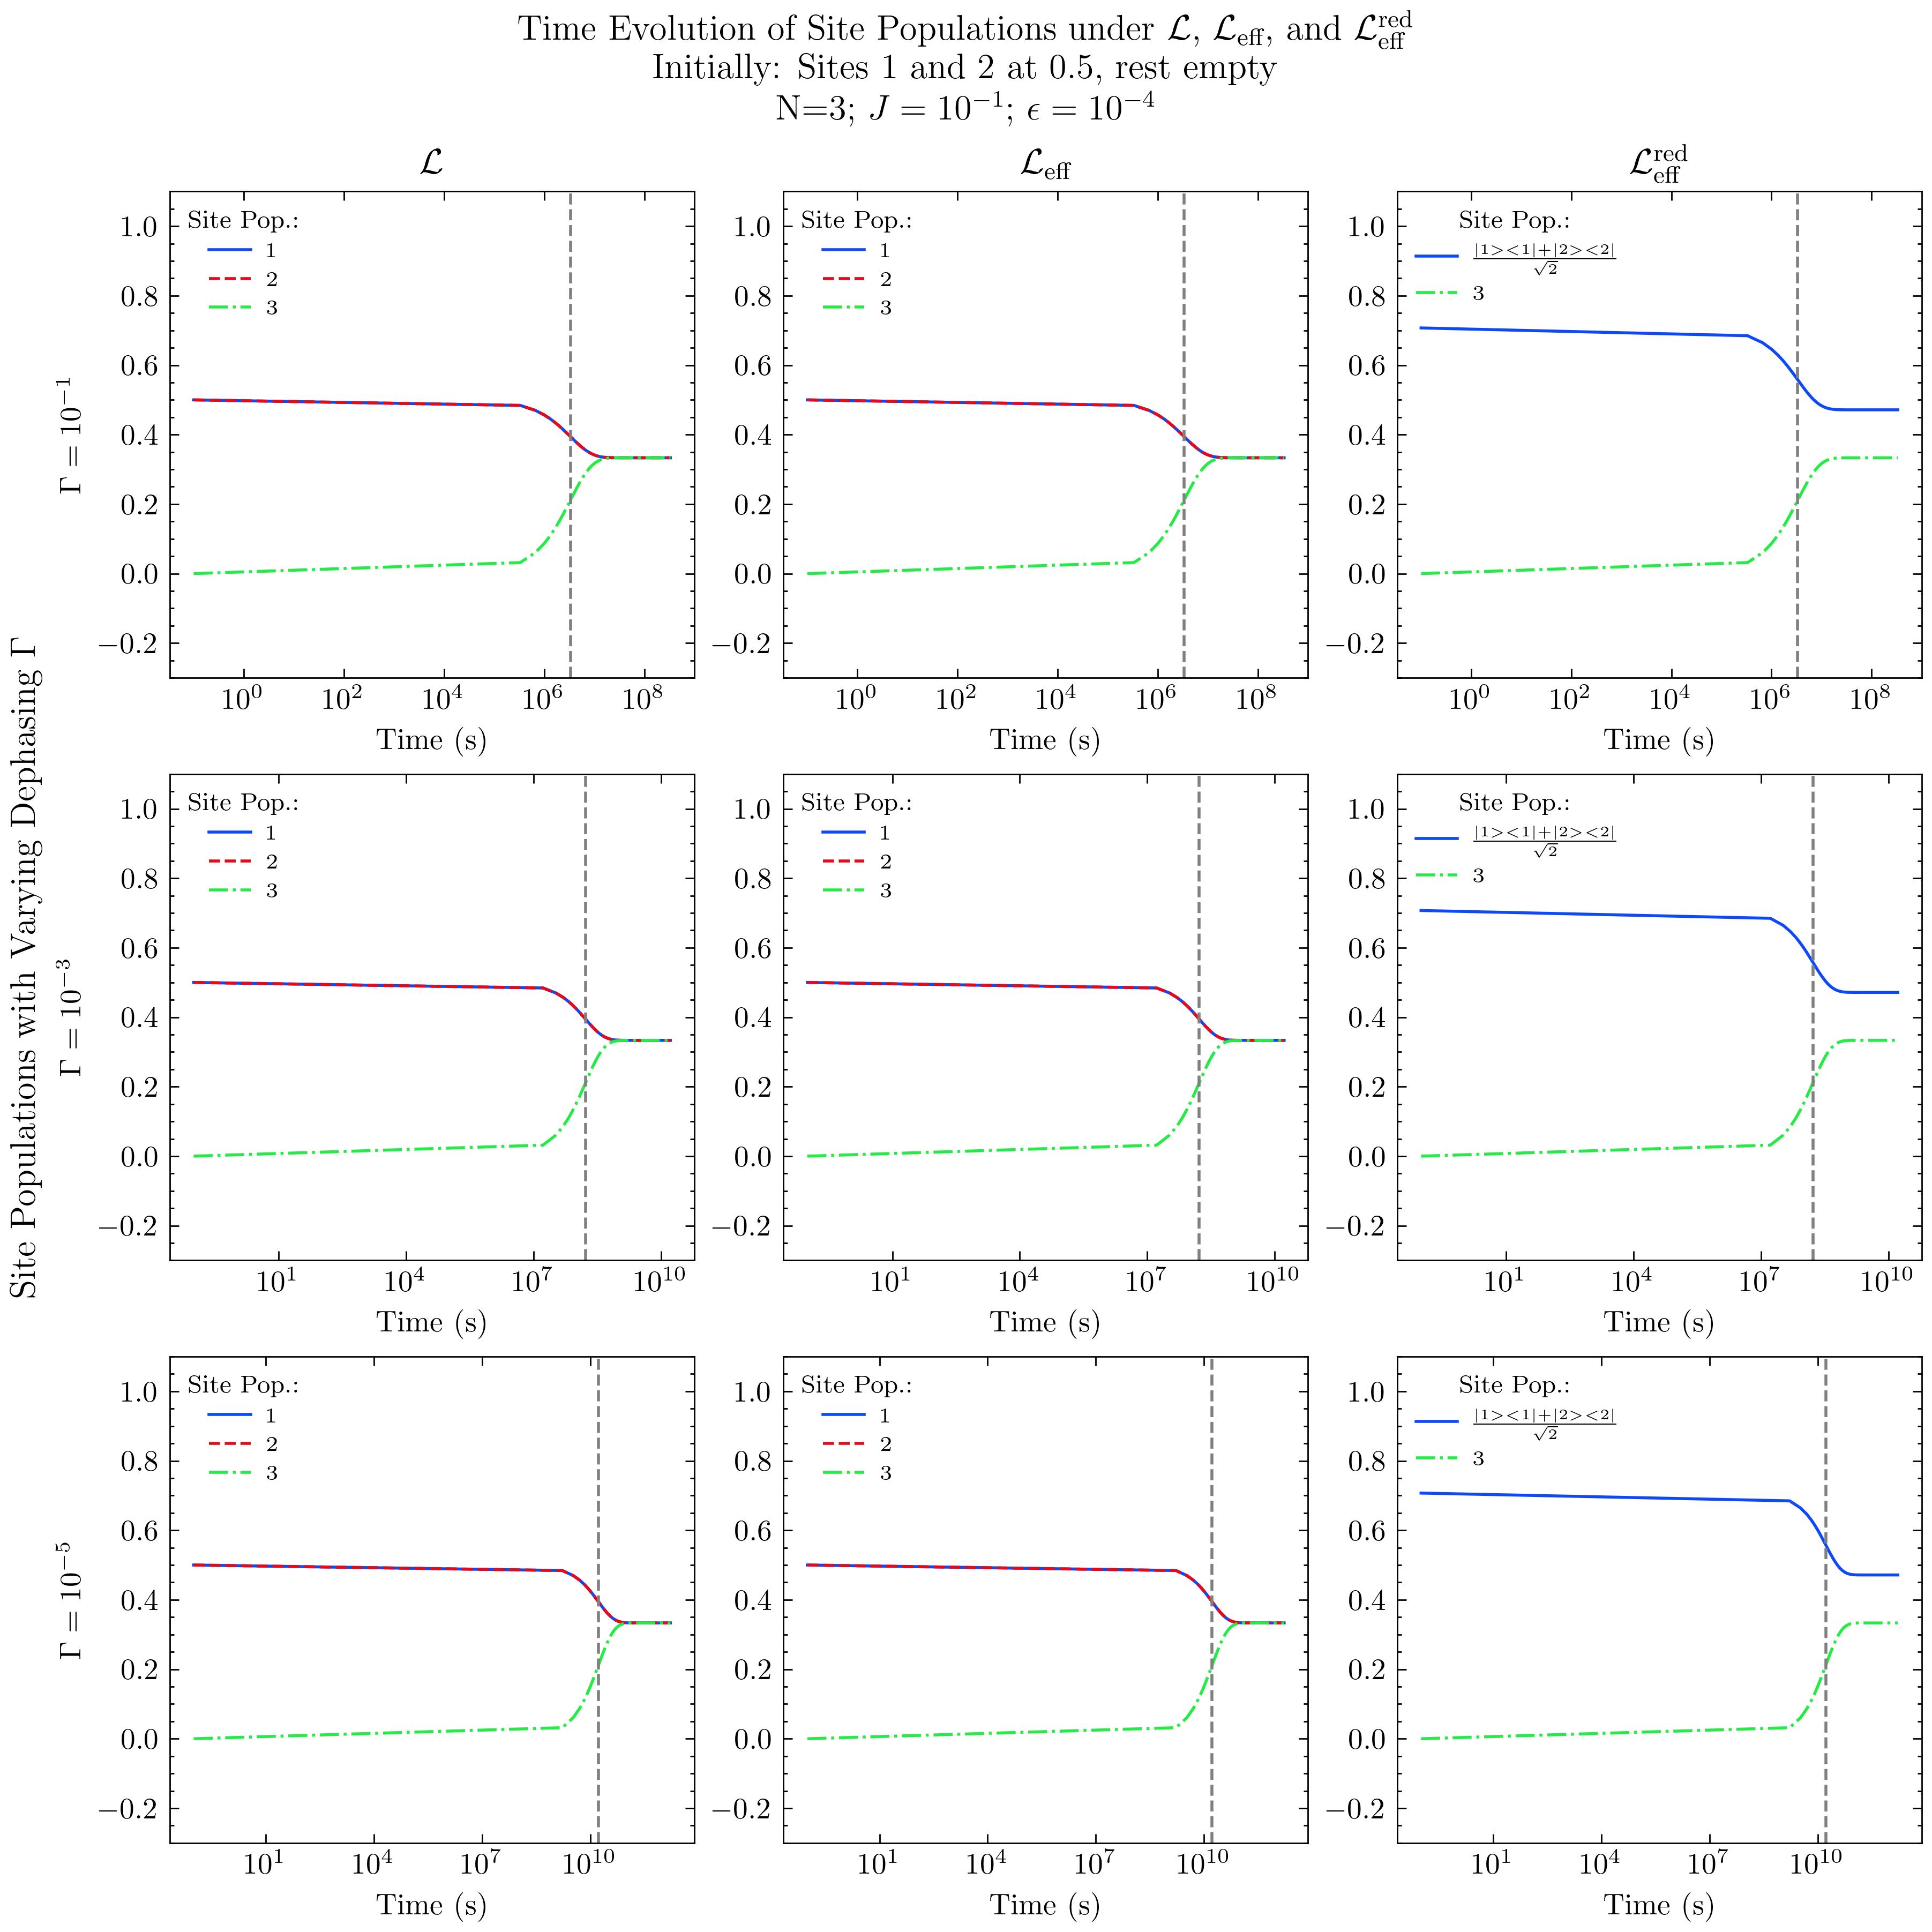

In [74]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 3

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Sites 1 and 2 at 0.5, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initiallysplit12; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

3333333.3333333335
166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334


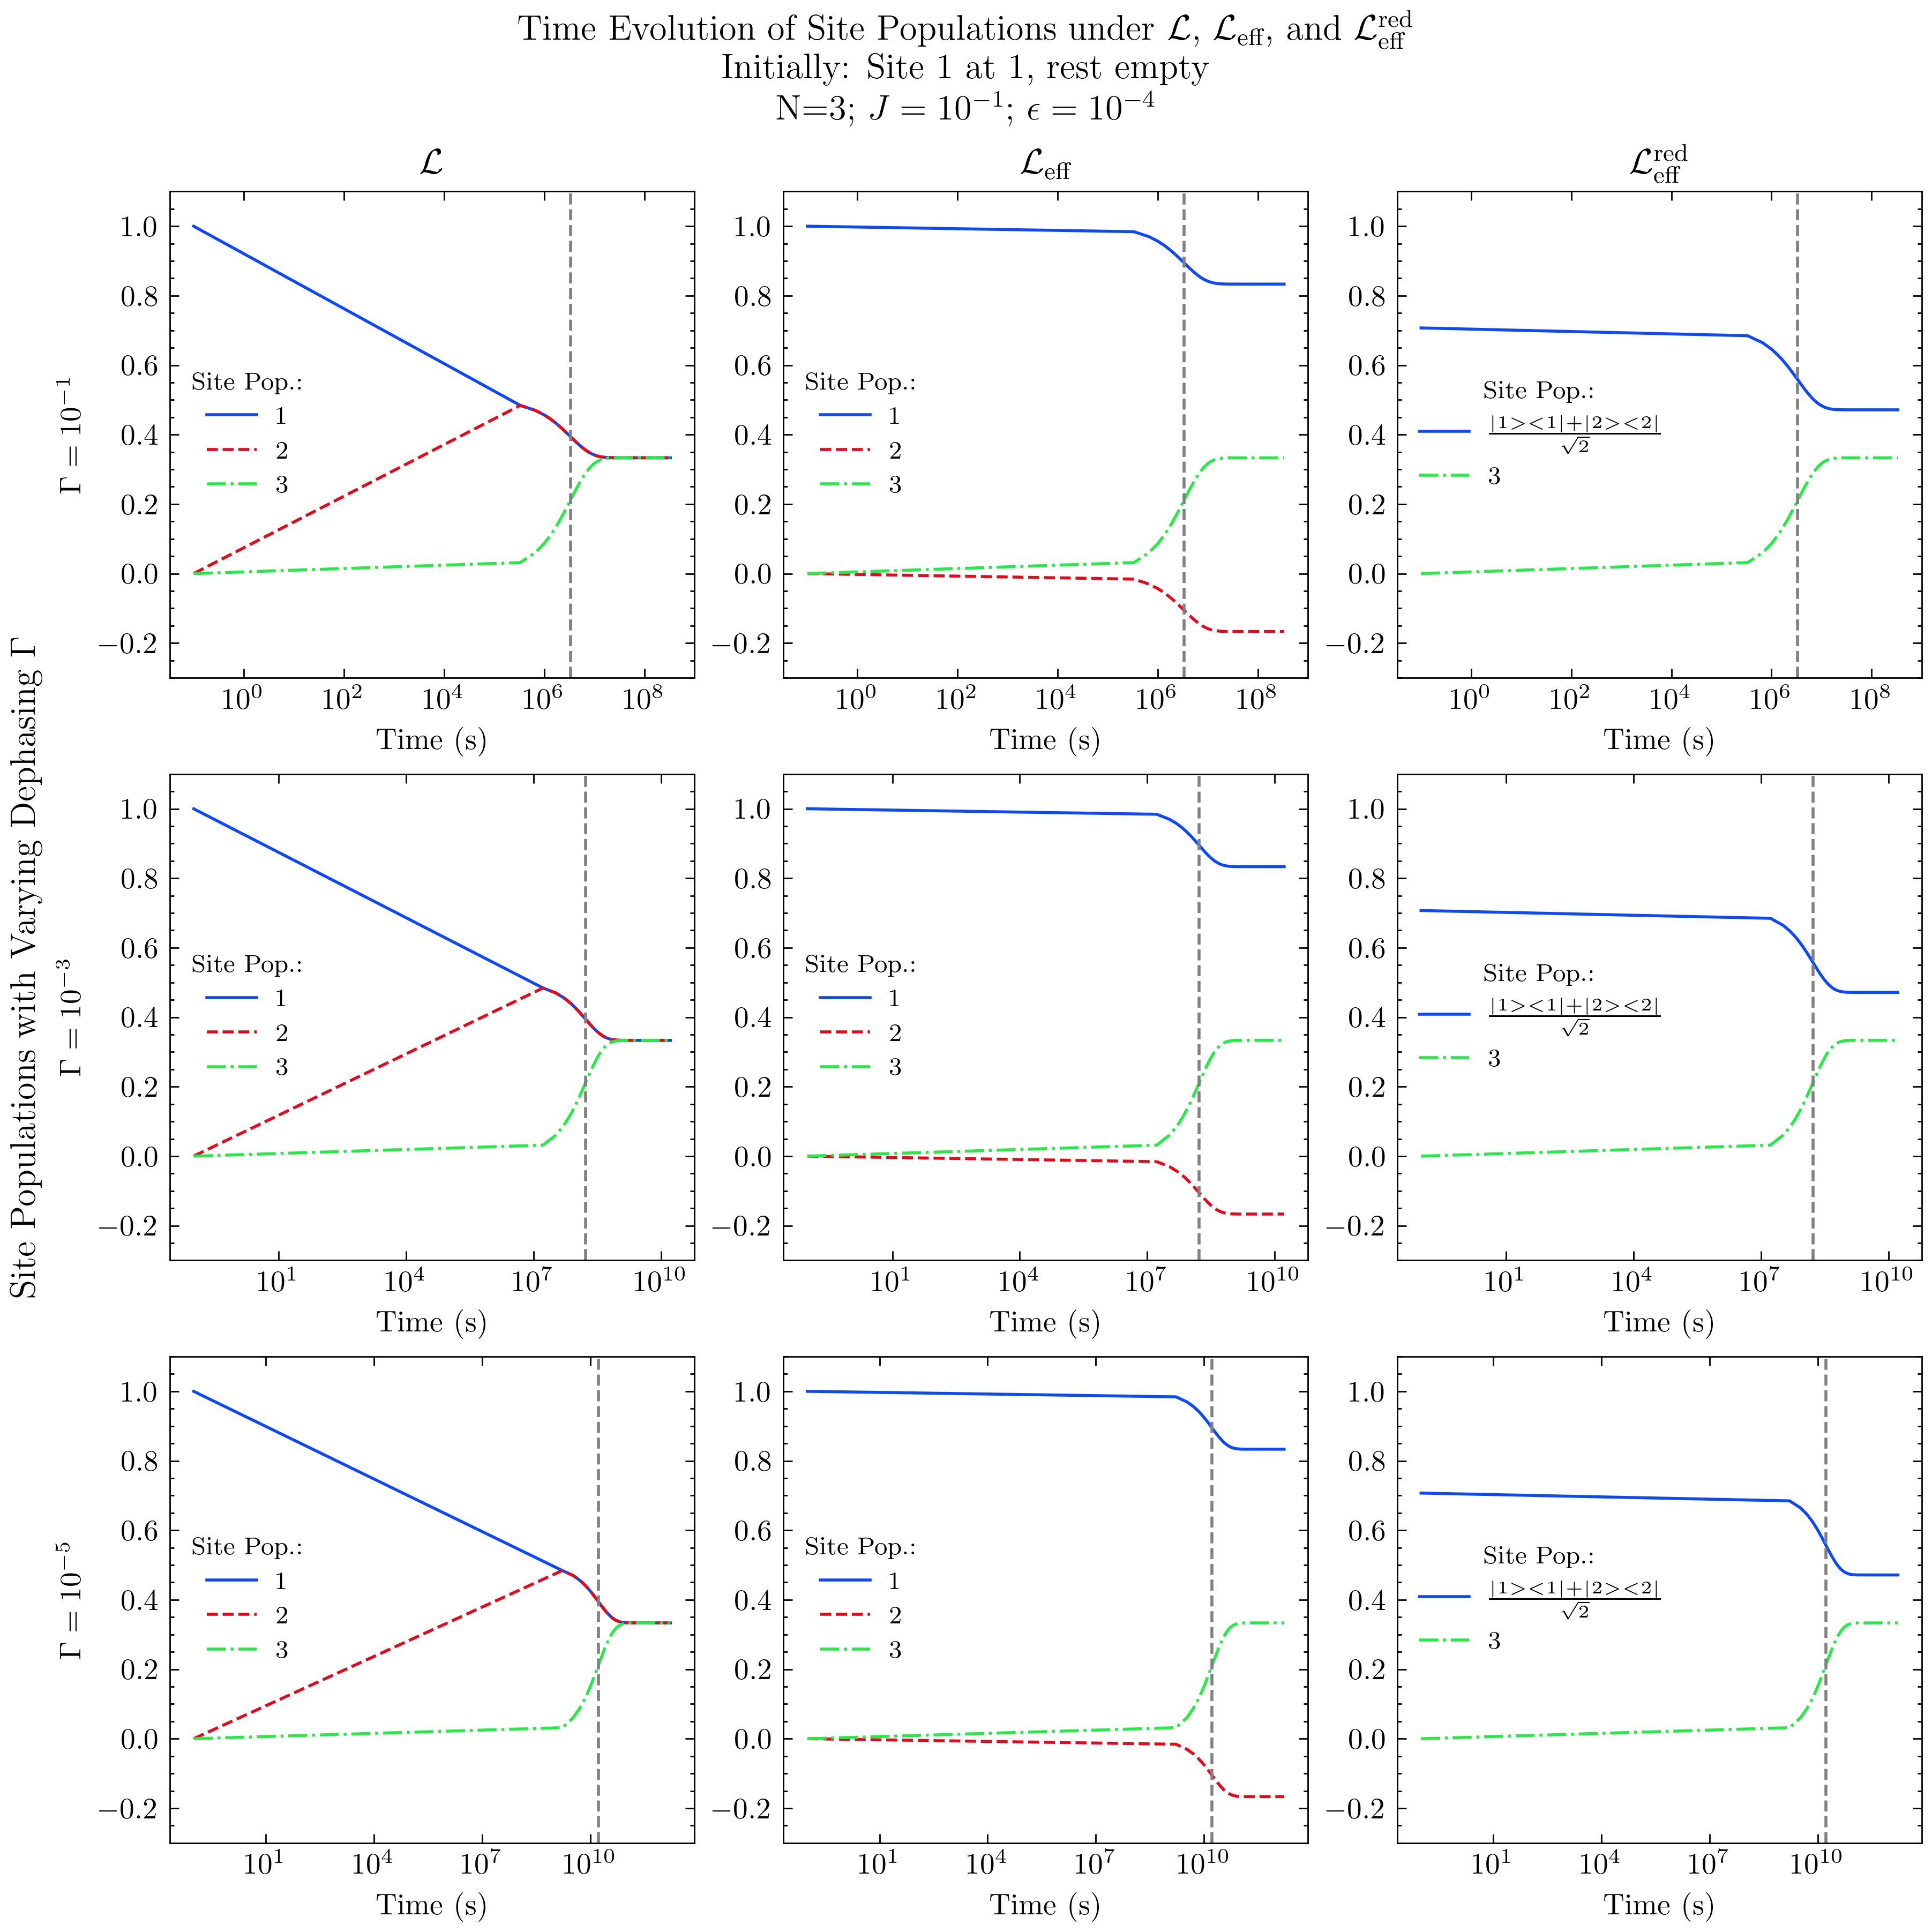

In [55]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 3

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 1 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially1; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

3333333.3333333335
166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334
3333333.3333333335
166683333.33333334
16666666833.333334


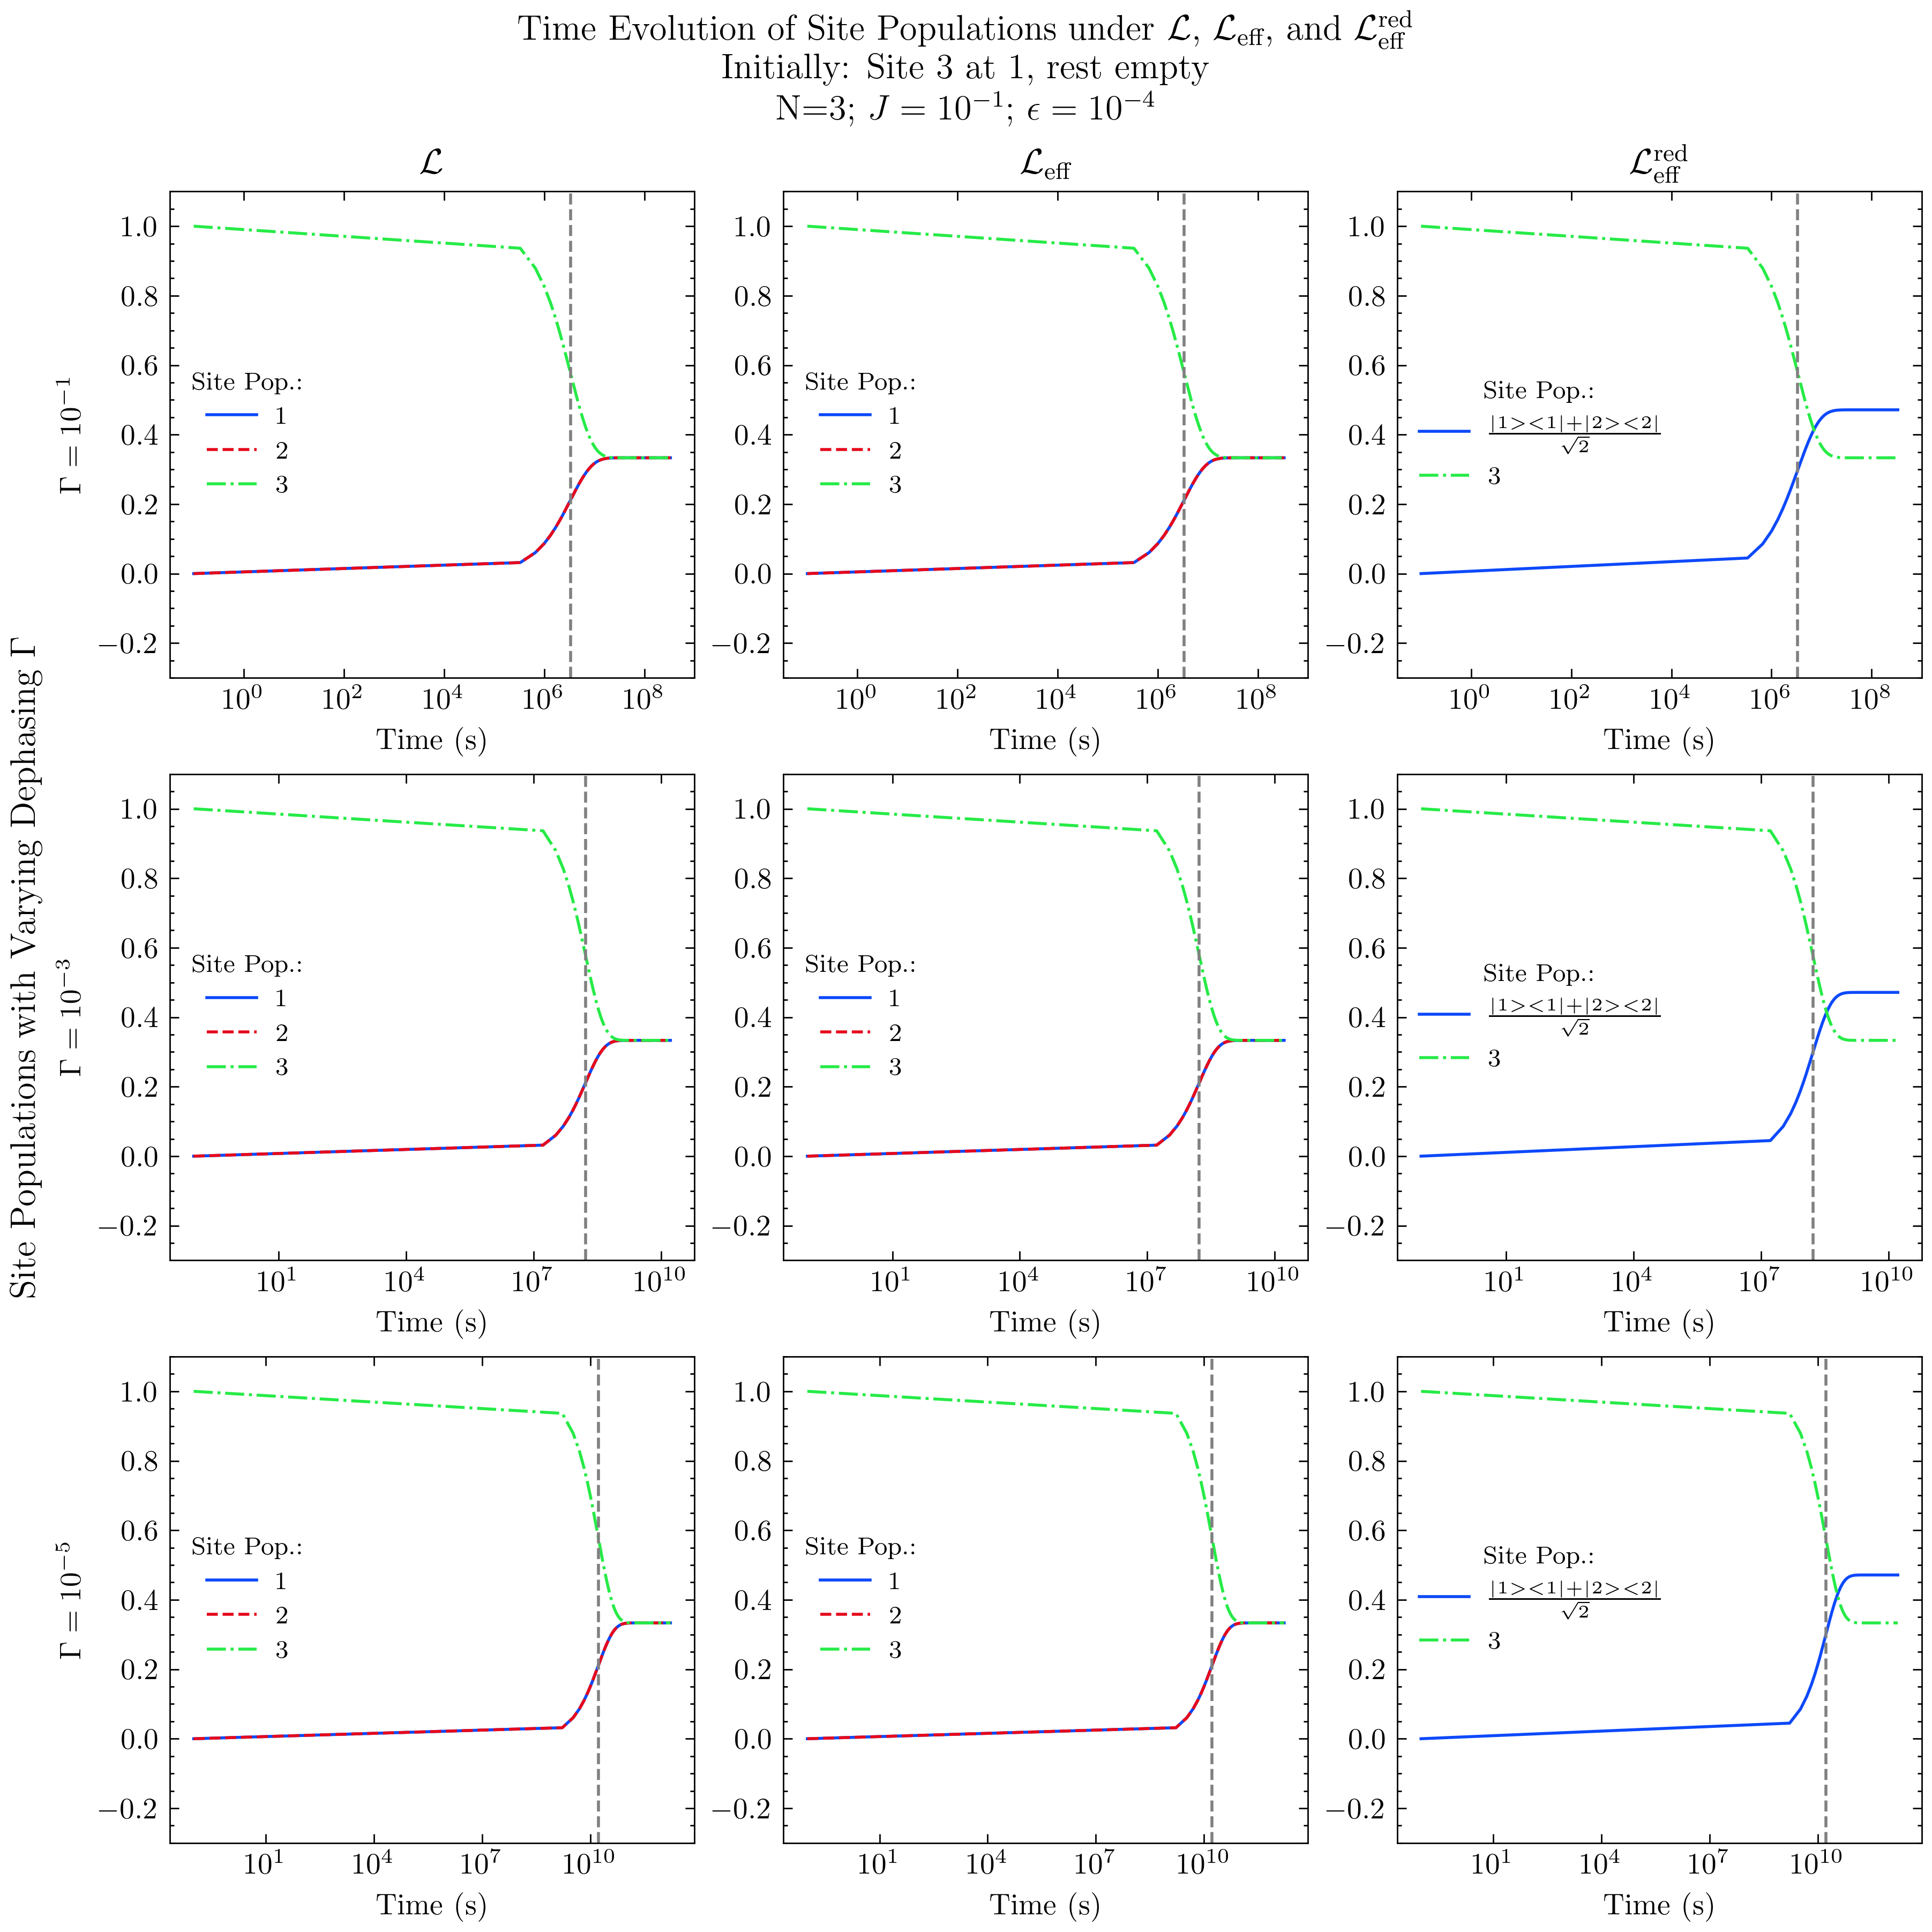

In [58]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 3

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1 if (i==1) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 3 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially3; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

# n = 4

2500000.0000000005


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0


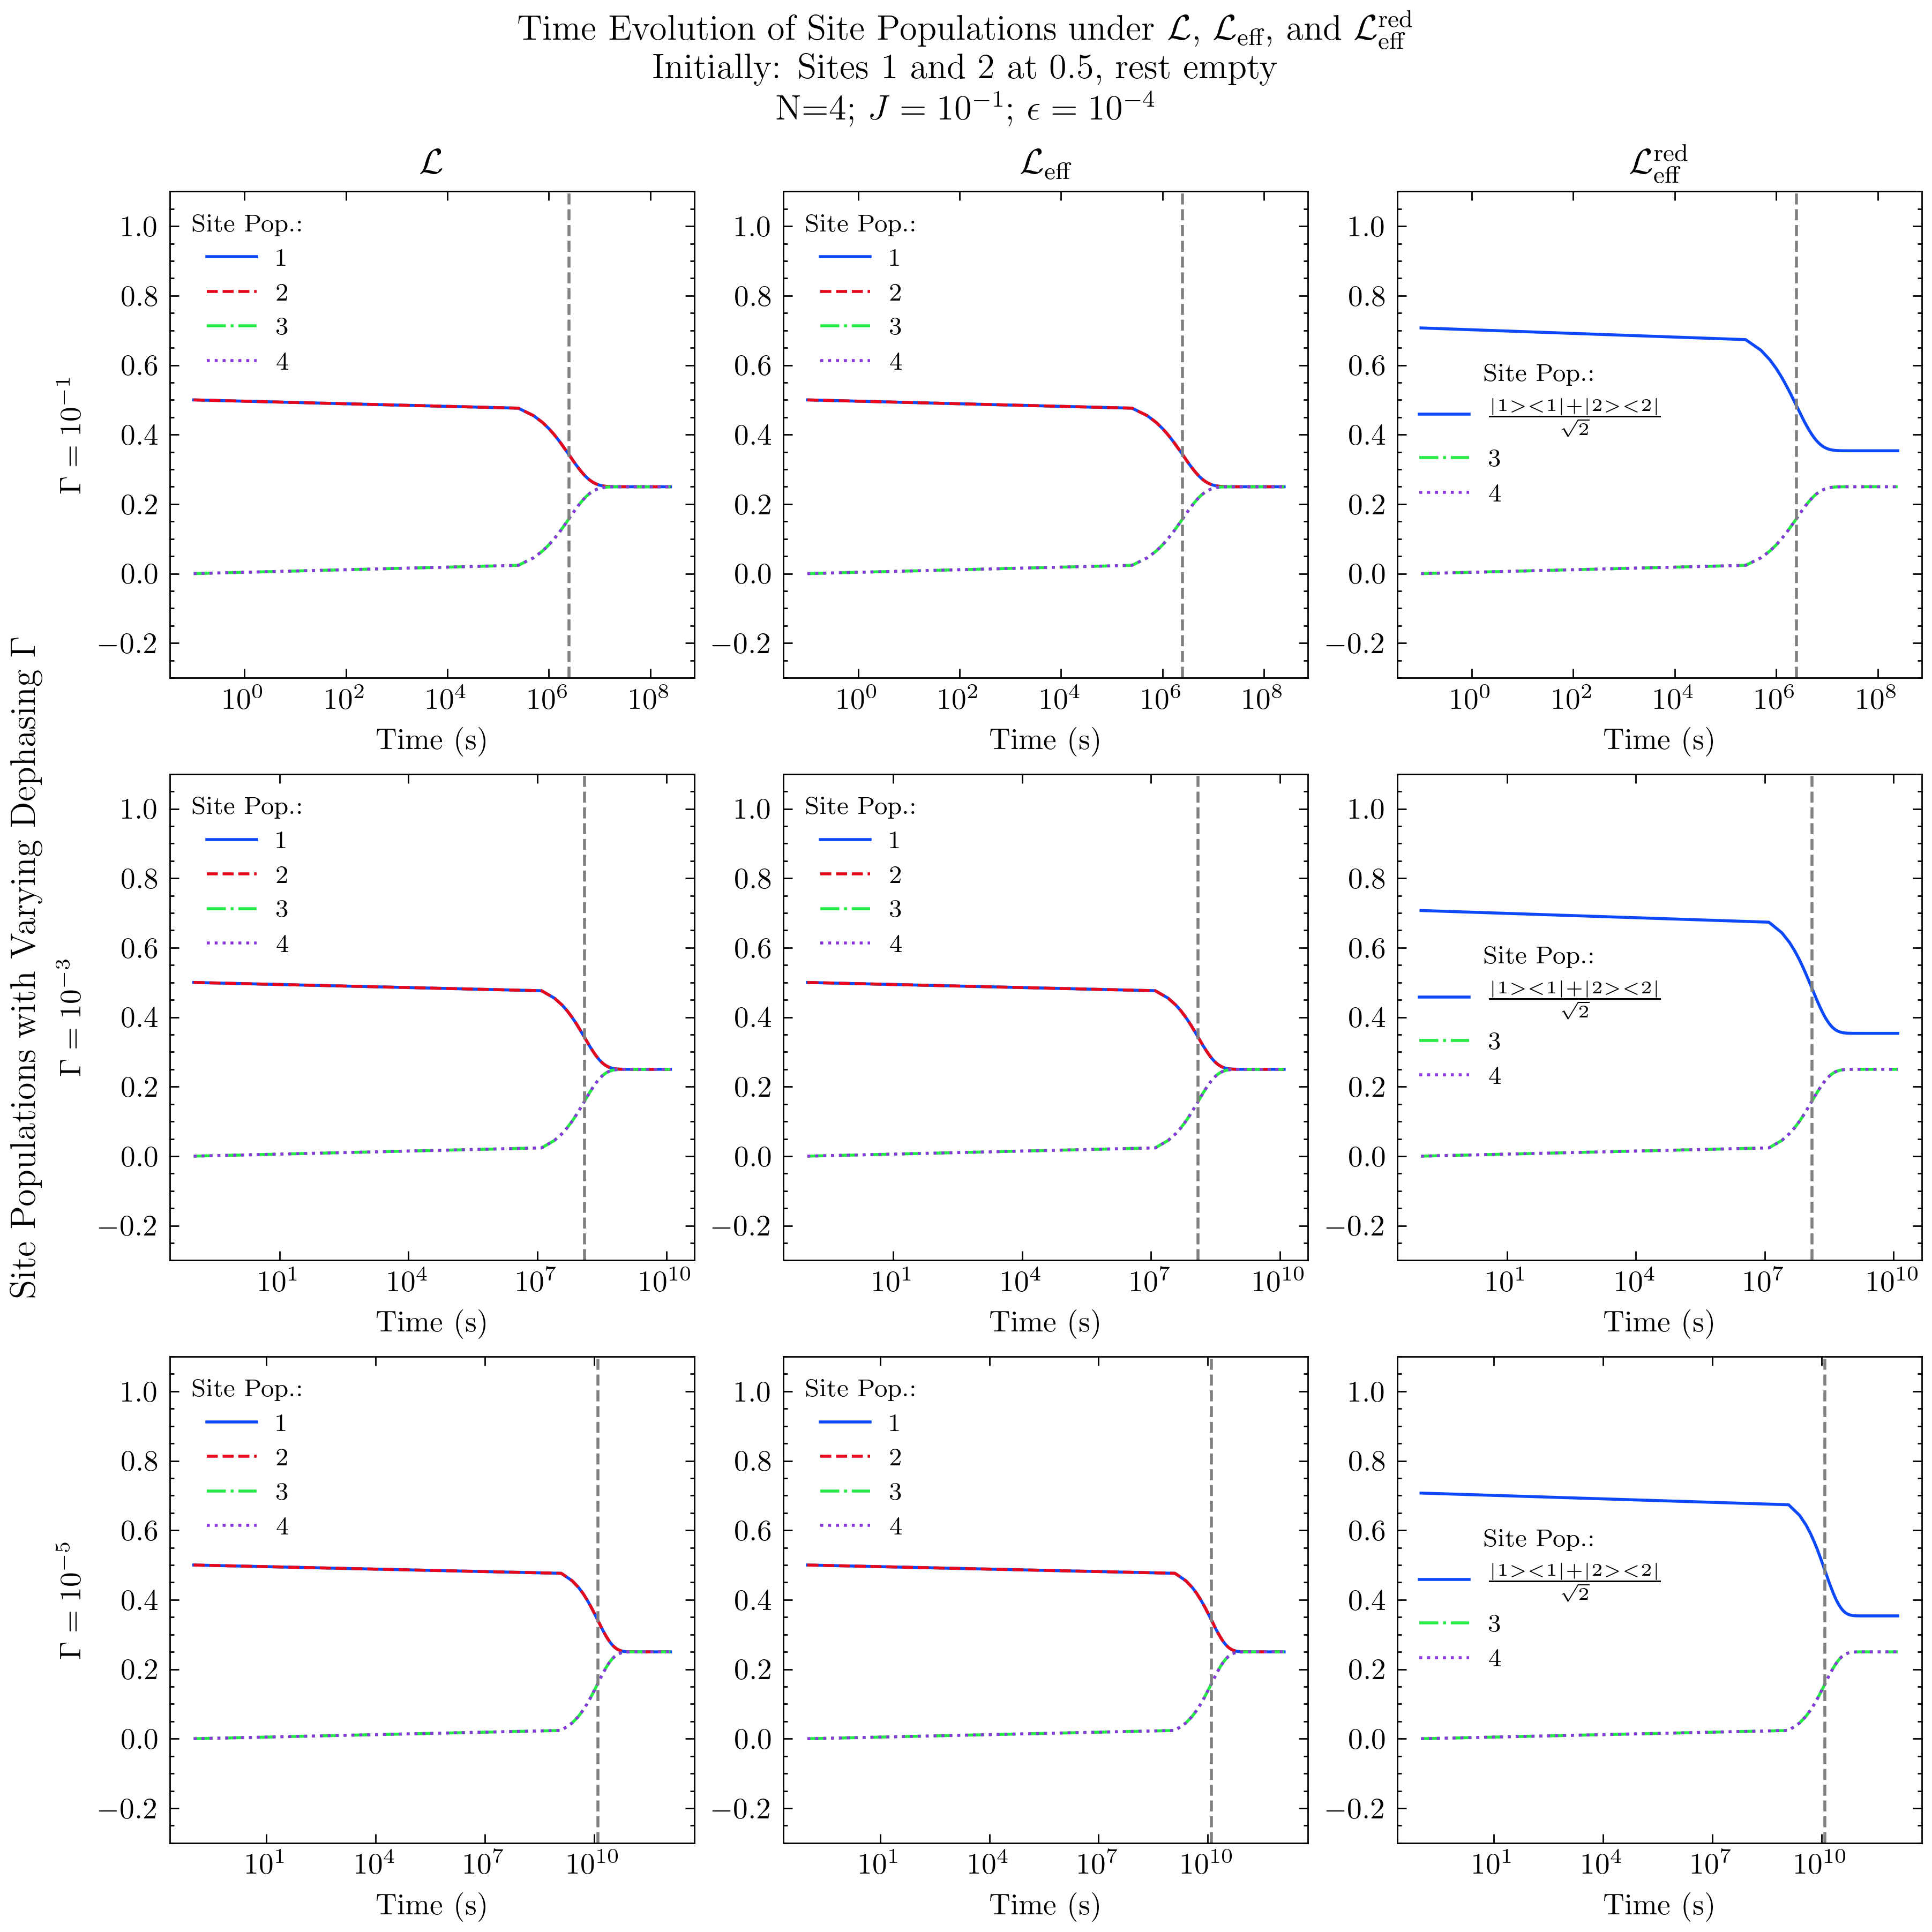

In [59]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 4

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Sites 1 and 2 at 0.5, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initiallysplit12; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

2500000.0000000005
125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0


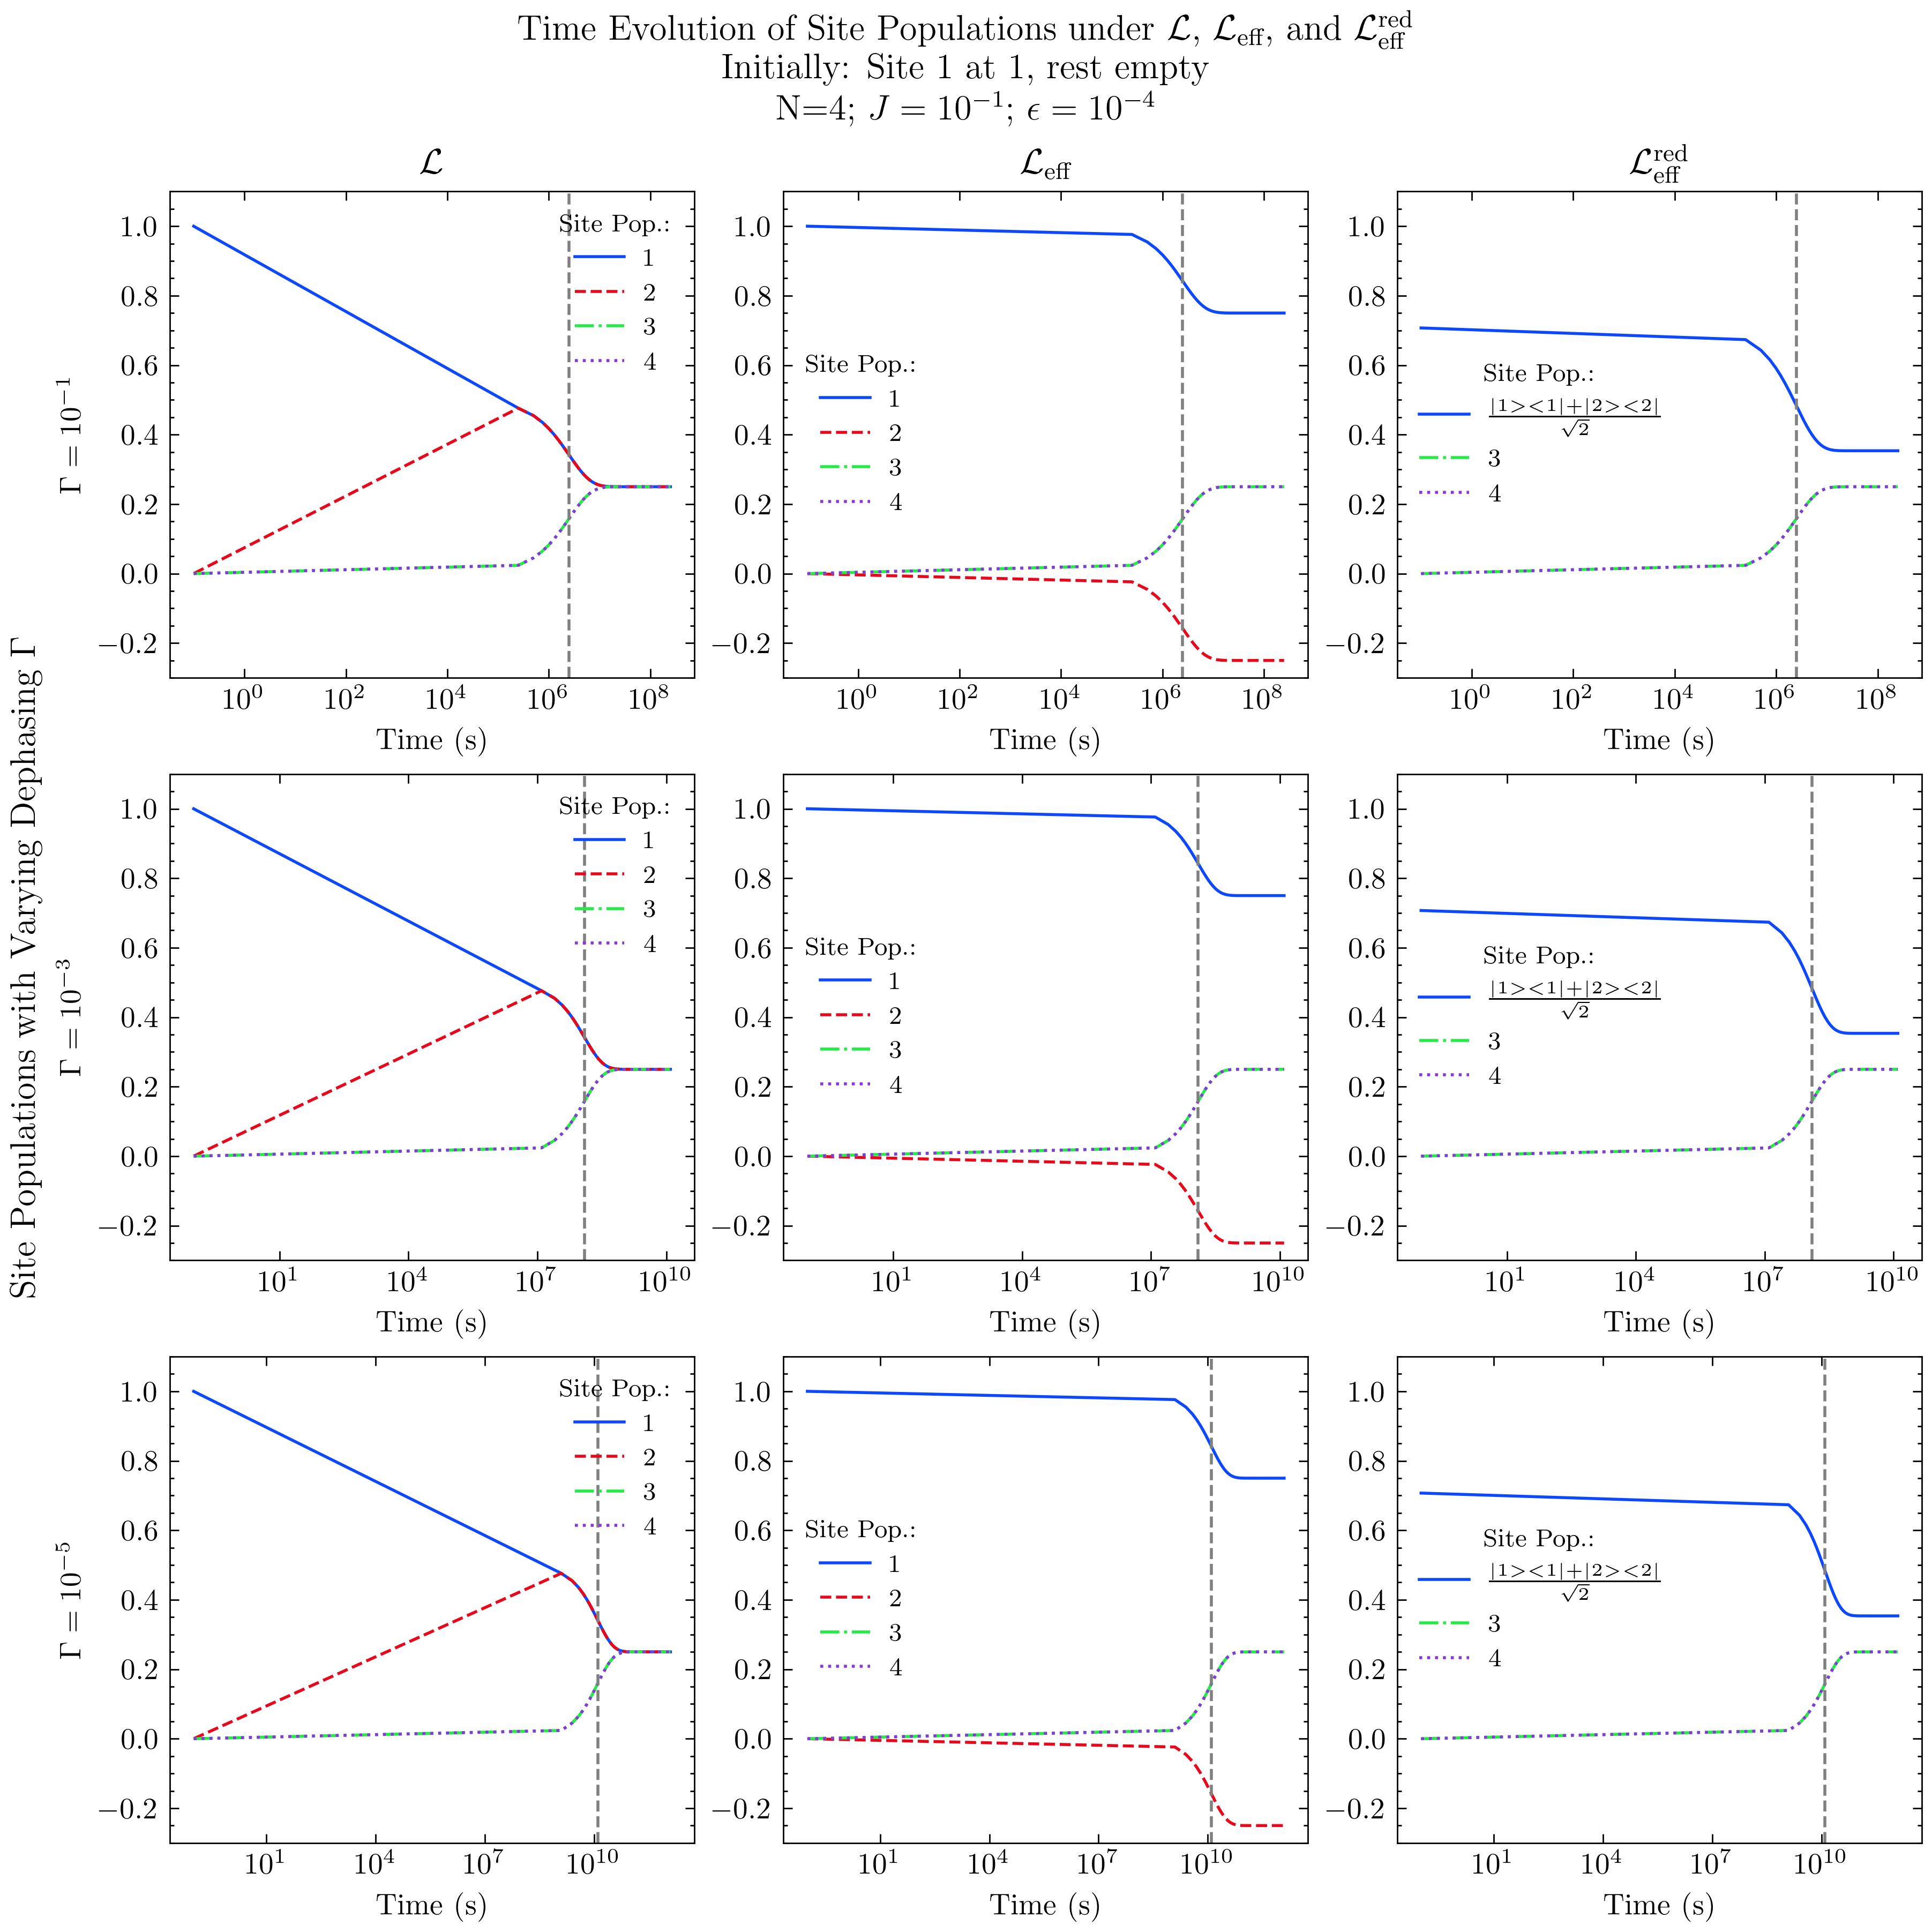

In [60]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 4

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 1 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially1; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

2500000.0000000005
125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0
2500000.0000000005
125012500.0
12500000125.0


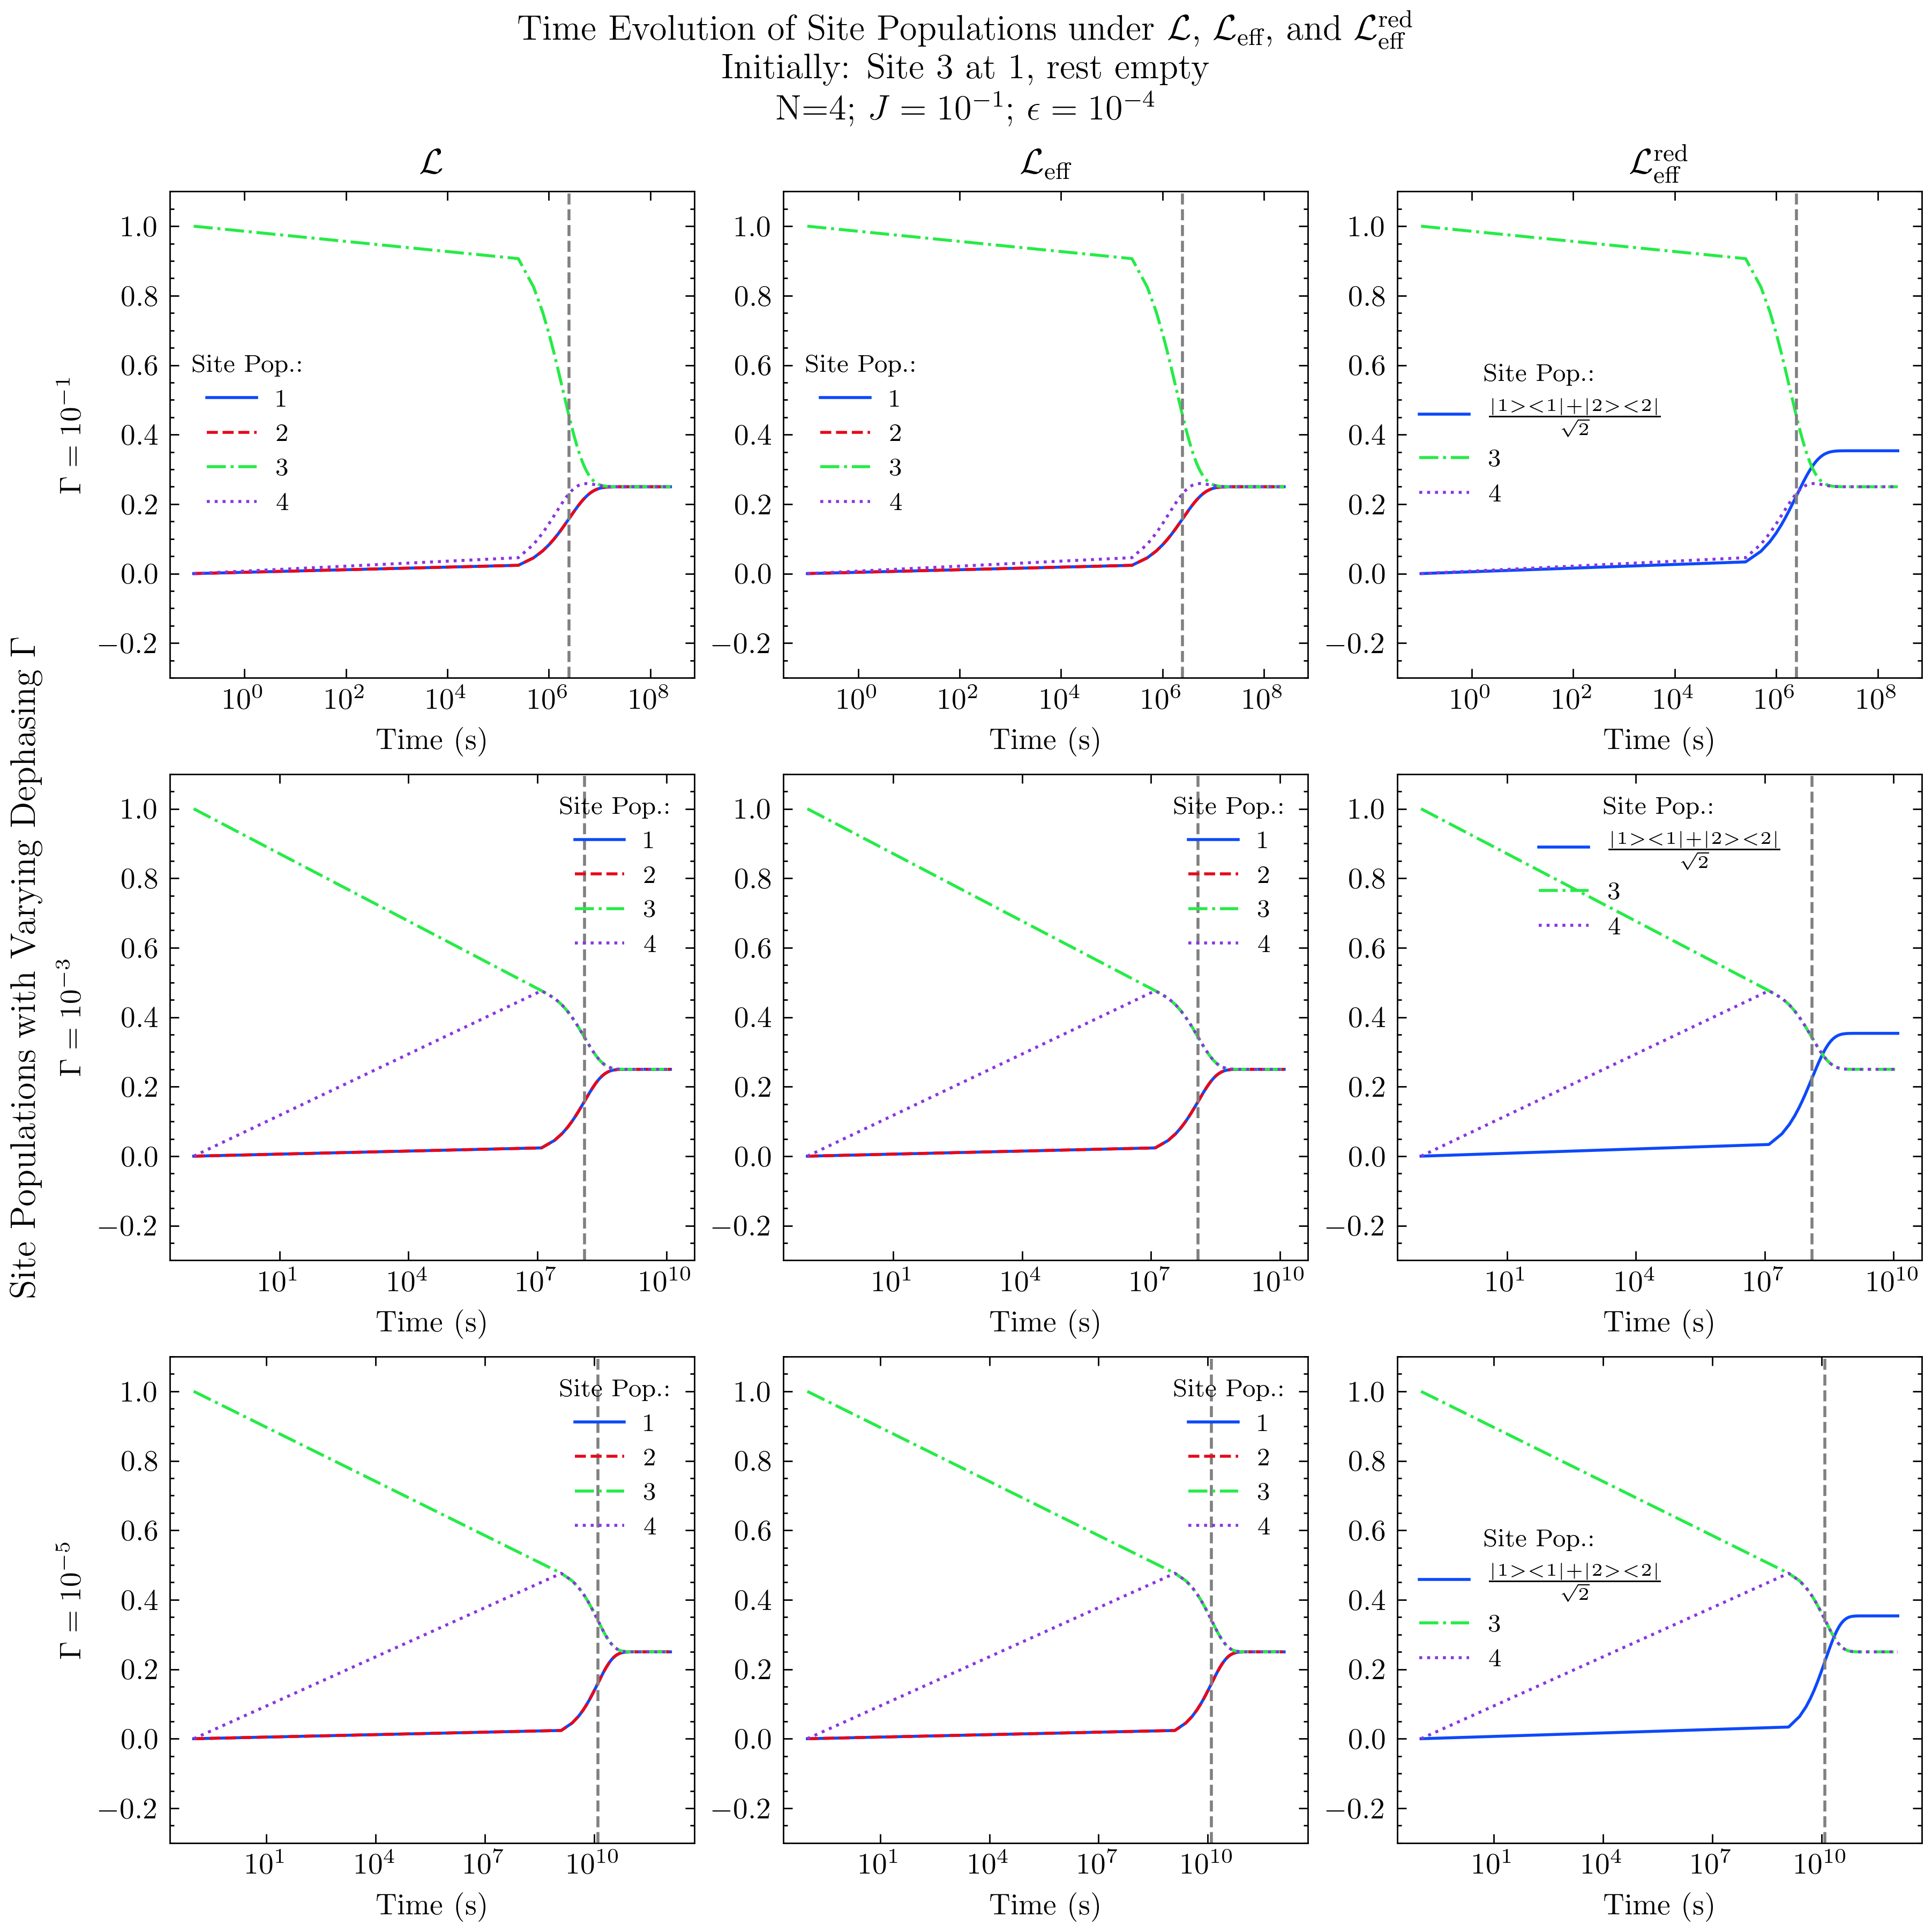

In [61]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 4

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1 if (i==1) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 3 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially3; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

# n = 5

2000000.0000000002
100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002


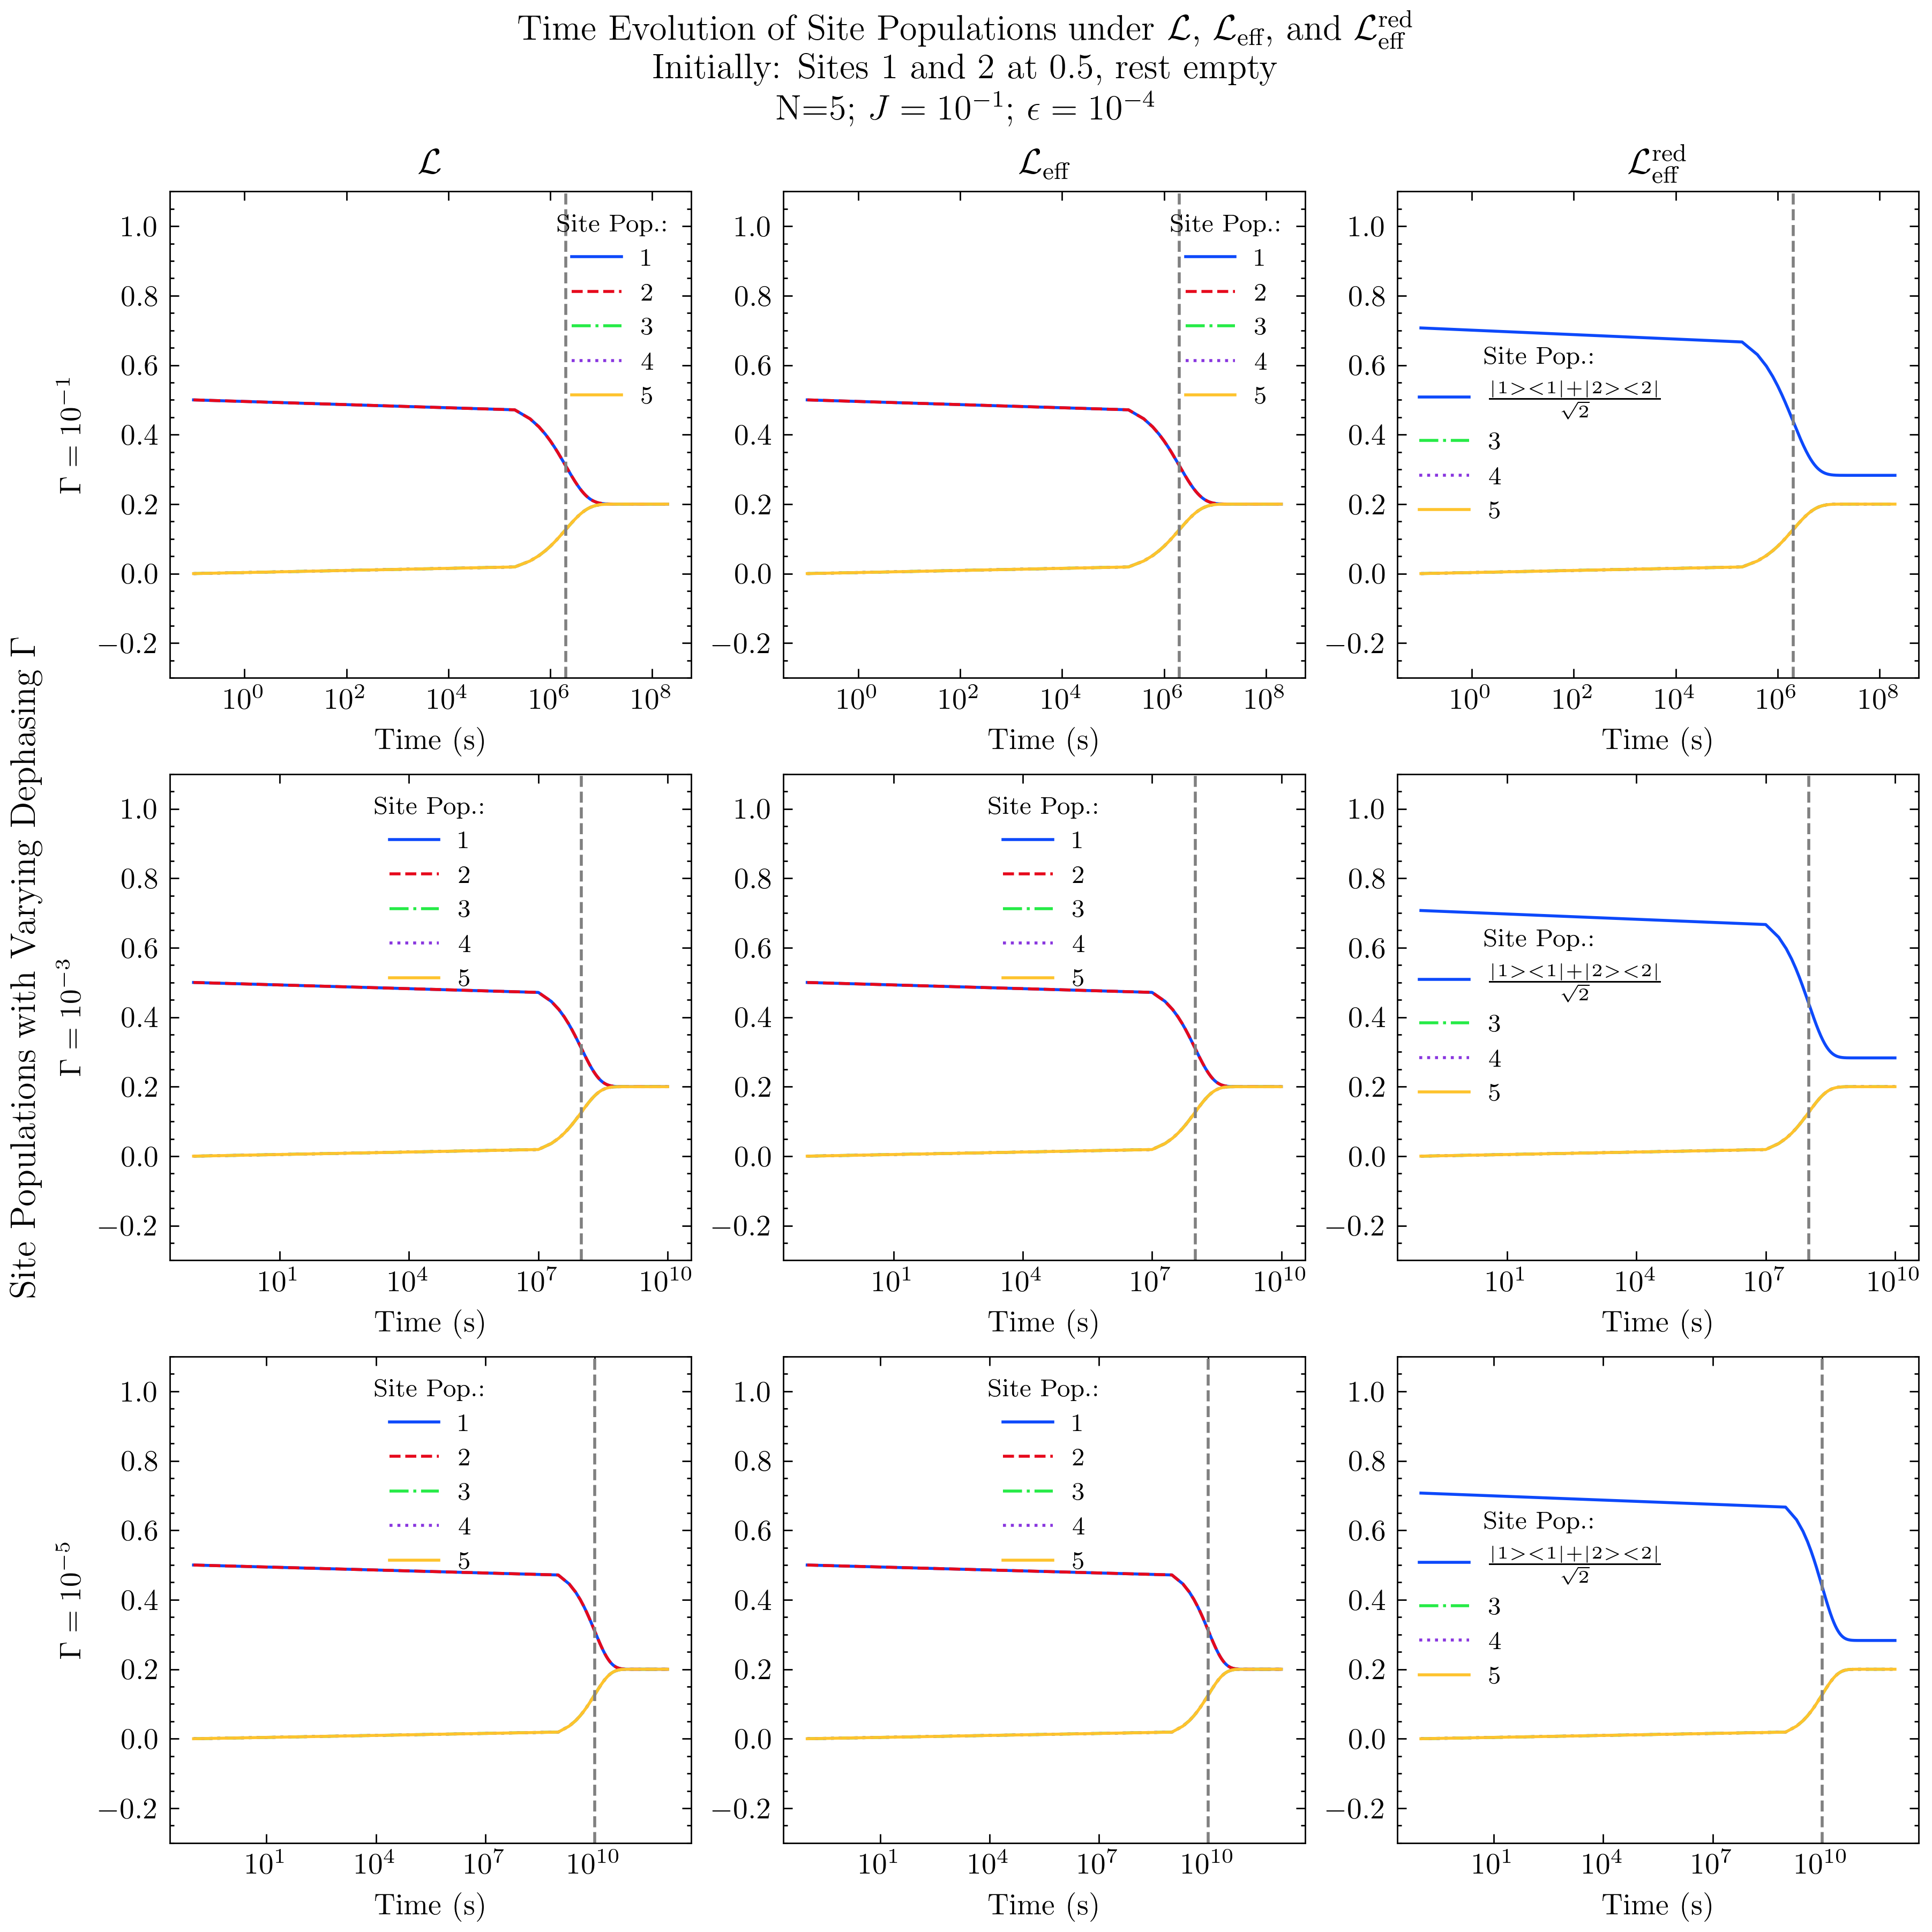

In [62]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 5

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([0.5 if (i==0 or i==(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Sites 1 and 2 at 0.5, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initiallysplit12; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

2000000.0000000002


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002


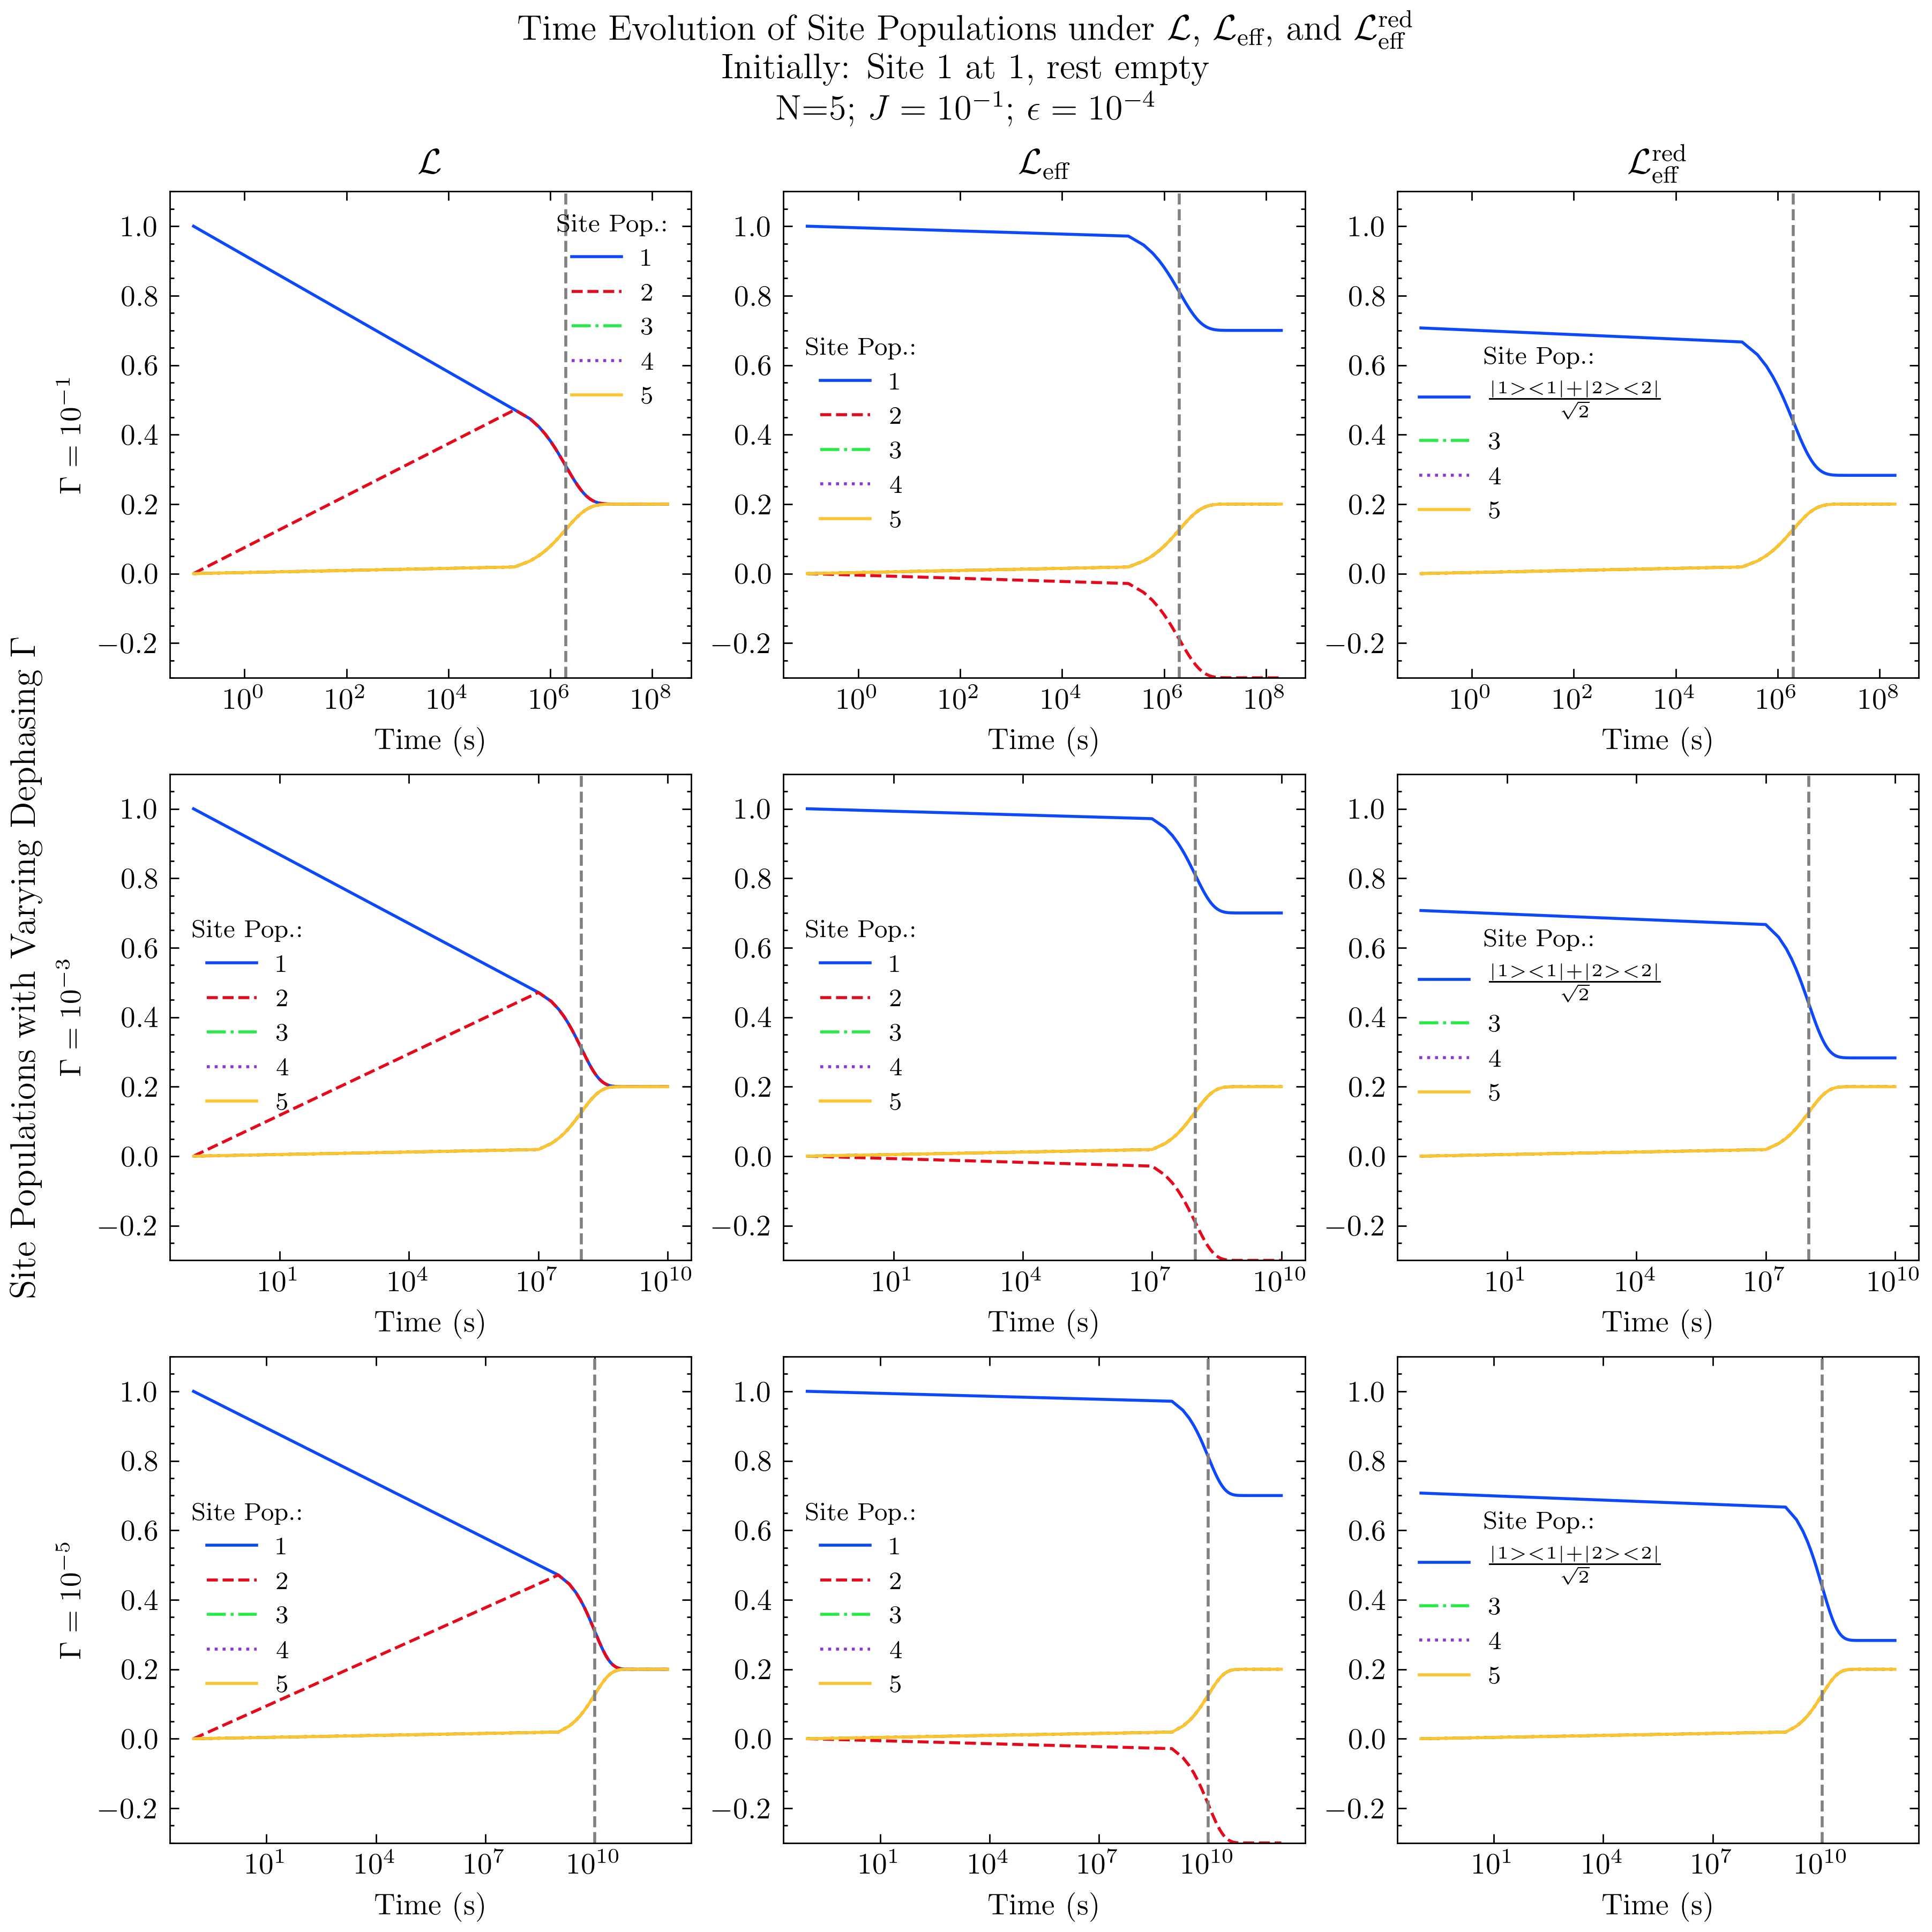

In [63]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 5

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==0) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1/np.sqrt(2) if (i==0) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 1 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially1; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

2000000.0000000002


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002
2000000.0000000002
100010000.00000001
10000000100.000002


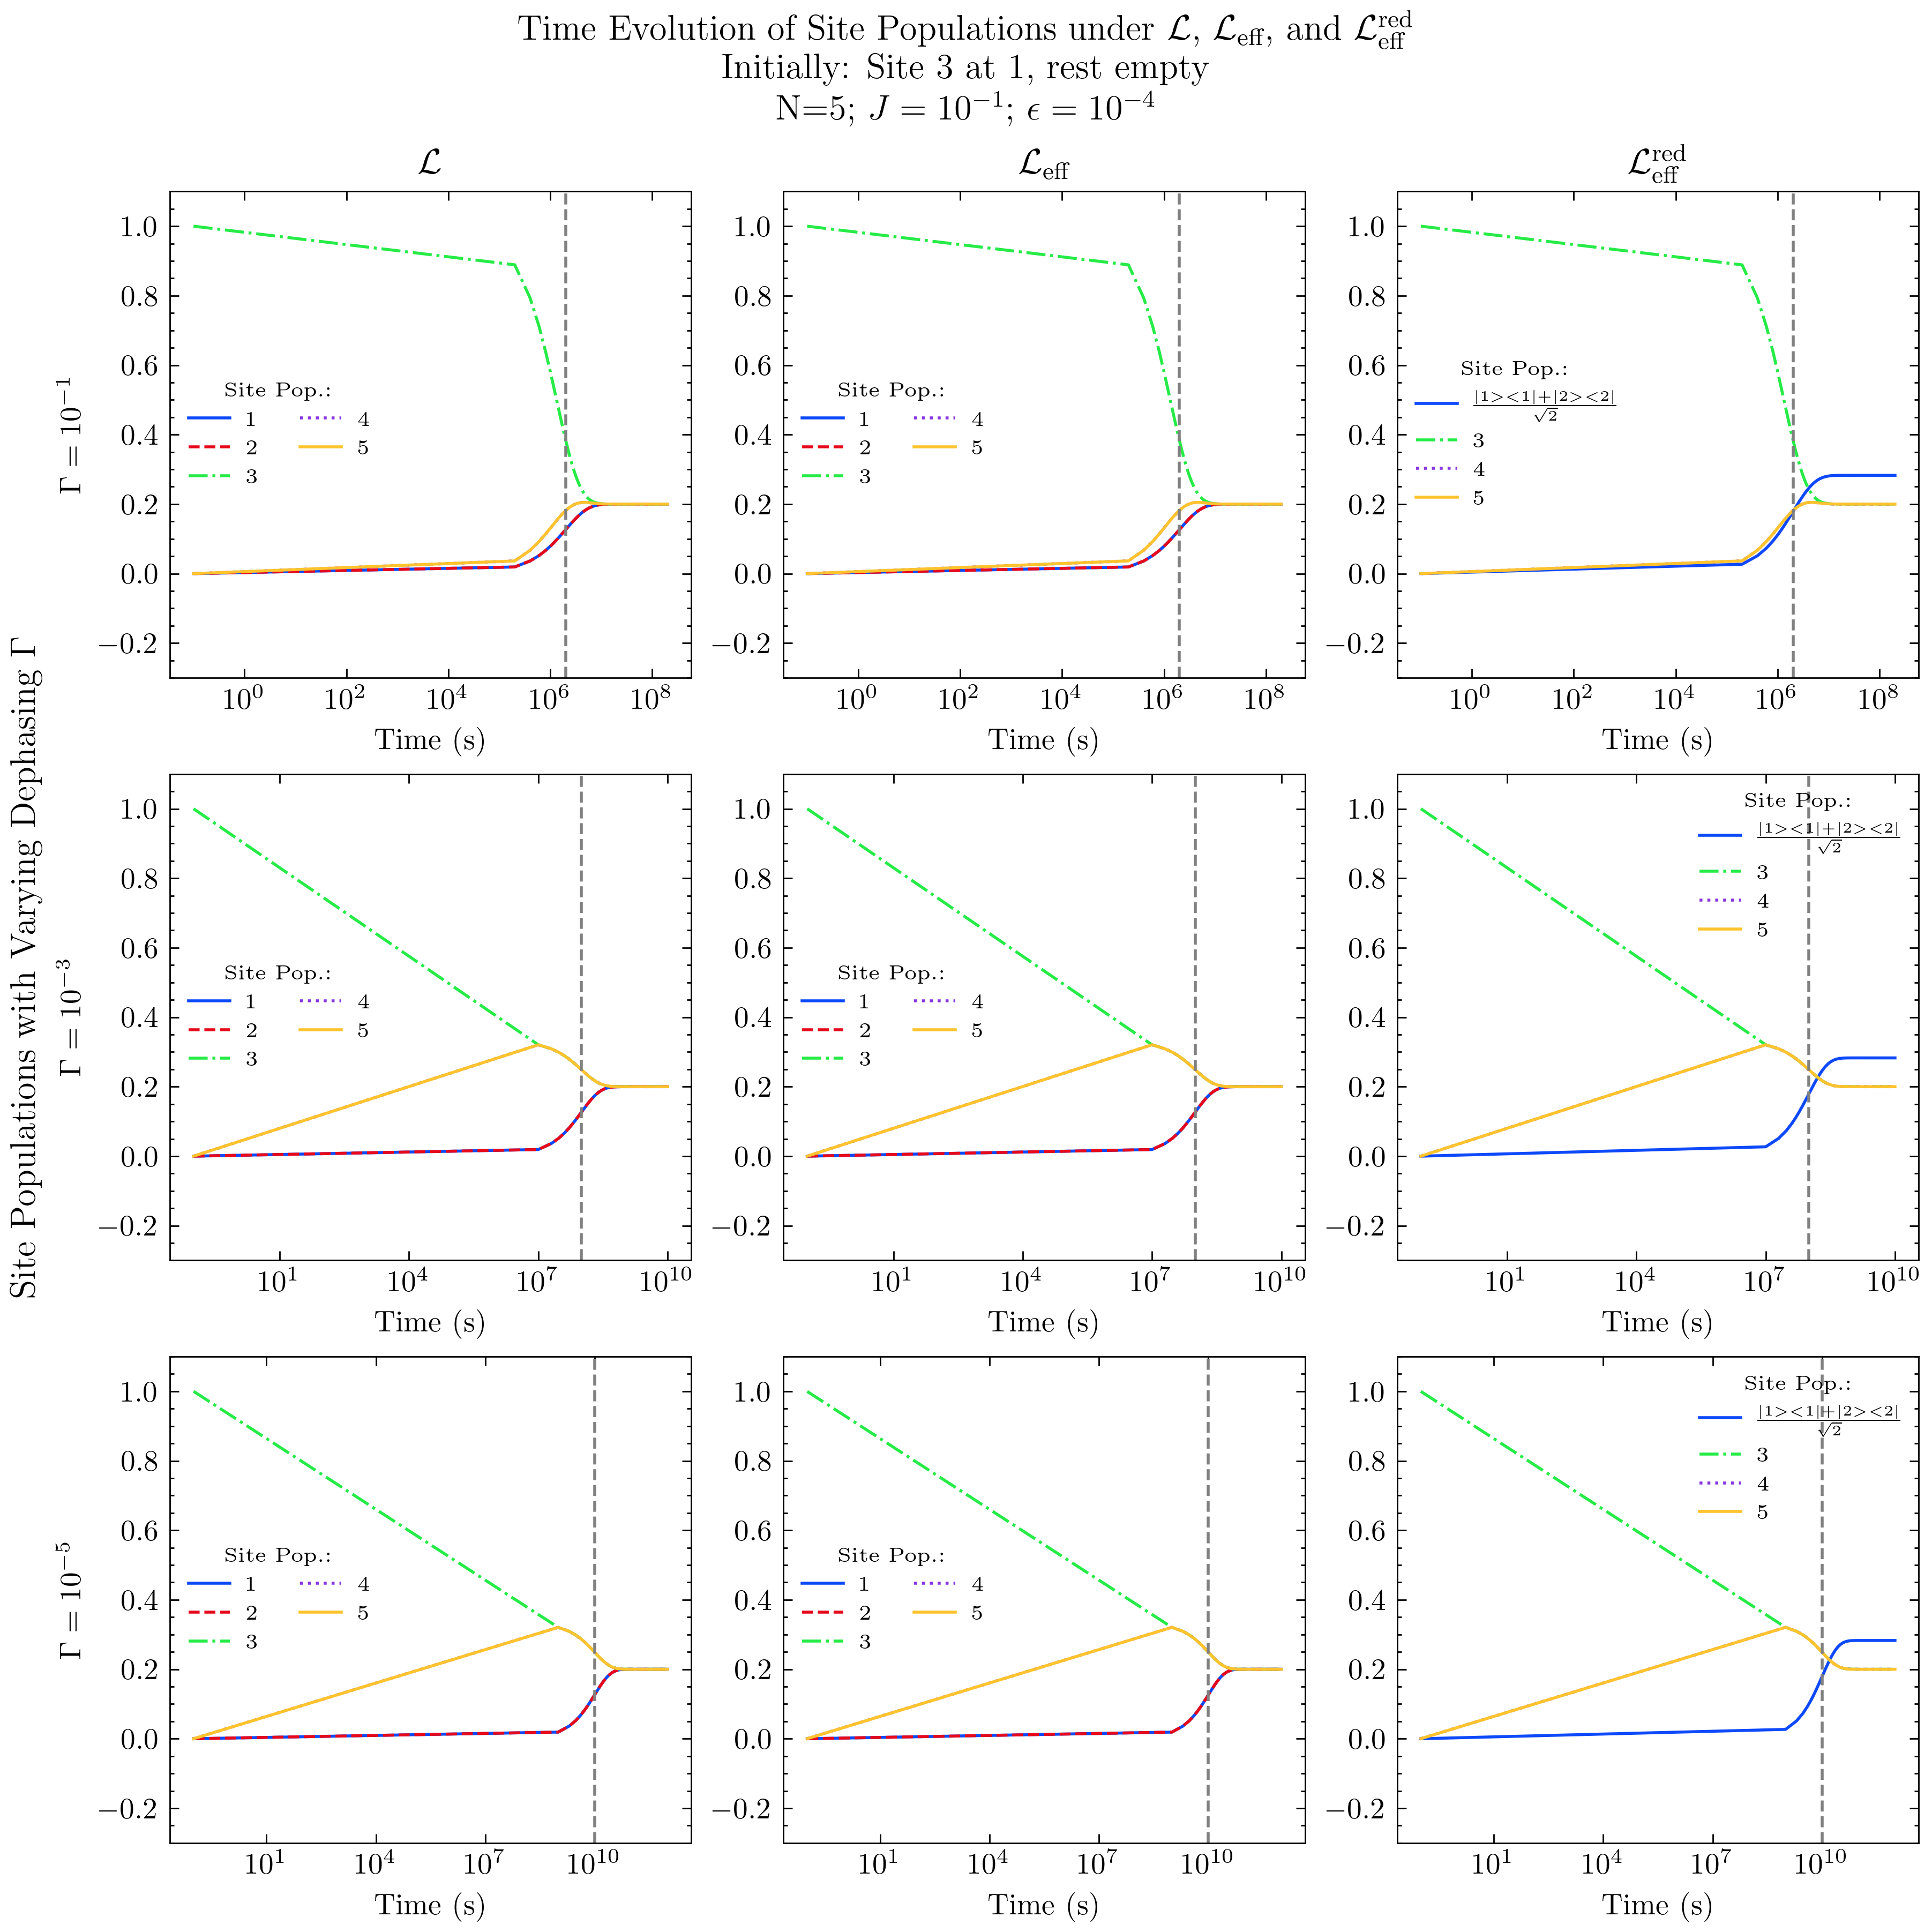

In [72]:
J_val = 0.1
epsilon_val = 1e-4
gamma_vals = [1e-1, 1e-3, 1e-5] 
N = 5

_, L, Leff, Leff_red = L_eff(N)

fig, axs = plt.subplots(3,3, figsize=(9, 9), layout='constrained')

plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,1], N, -1*Leff, J_val, epsilon_val, gamma_vals, np.array([1 if (i==2*(N+1)) else 0 for i in range(N**2)]), (N+1)*np.arange(N), False)
plot_time_series(axs[:,2], N, -1*Leff_red, J_val, epsilon_val, gamma_vals, np.array([1 if (i==1) else 0 for i in range(N-1)]), np.arange(N-1), False, reduced_matrix=True)

for i, val in enumerate(gamma_vals):
    axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')

axs[0,0].set_title(r"$\mathcal{L}$")
axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")

fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + "Initially: Site 3 at 1, rest empty" + "\n" + rf"N={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

fig.savefig(f"N={N}; initially3; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")